## Going to vomit the little knowledge I have on multiple linear regression..

In [325]:
import copy, math
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [345]:
data = pd.read_csv("Student_Performance.csv")
mapping = {'Yes':1, 'No':0}
data['Extracurricular Activities'] = data['Extracurricular Activities'].map(mapping).astype(int)
x_train = np.array(data.iloc[:100 ,:5])
y_train = np.array(data.iloc[:100, 5])

In [346]:
b_init = 50.0
w_init = np.array([ 1 for i in range(5)])

In [347]:
def predict(x, w, b):

    p = np.dot(w, x) + b
    return p

In [348]:
x_vec = x_train[0, :]
print(f"x_vec shape {x_vec.shape}, x_vec value: {x_vec}")

# make a prediction
f_wb = predict(x_vec, w_init, b_init)
print(f"f_wb shape {f_wb.shape}, prediction: {f_wb}")

x_vec shape (5,), x_vec value: [ 7 99  1  9  1]
f_wb shape (), prediction: 167.0


In [349]:
def compute_cost(x, y, w, b):
    cost = 0.0
    m = x.shape[0]
    for i in range(m):
        f_wb_i = np.dot(w, x[i]) + b
        cost = cost + (f_wb_i - y[i])**2
    cost = np.mean(cost)/2
    return cost

In [350]:
cost = compute_cost(x_train, y_train, w_init, b_init)
print(f'Cost at optimal w : {cost}')

Cost at optimal w : 320410.0


In [351]:
def compute_gradient(x, y, w, b):
    m,n = x.shape
    dj_dw = np.zeros((n,))
    dj_db = 0.

    for i in range(m):
        err = (np.dot(x[i], w) + b) - y[i]
        for j in range(n):
            dj_dw[j] += err*x[i,j]
        dj_db += err
    dj_dw = dj_dw/m
    dj_db = np.mean(dj_db)

    return dj_db, dj_dw

In [352]:
#Compute and display gradient 
tmp_dj_db, tmp_dj_dw = compute_gradient(x_train, y_train, w_init, b_init)
print(f'dj_db at initial w,b: {tmp_dj_db}')
print(f'dj_dw at initial w,b: \n {tmp_dj_dw}')

dj_db at initial w,b: 7984.0
dj_dw at initial w,b: 
 [ 411.5  5642.16   46.73  517.93  312.87]


Gradient Descent With Multiple Variables|

In [357]:
def gradient_descent(x, y, w_in, b_in, cost_function, gradient_function, alpha, iter):
    J_history = []
    w_1_hist = []
    w = copy.deepcopy(w_in)
    b = b_in

    print("Iteration Cost        w0        w1        w2        w3        w4       b     "
          "dj_dw0  dj_dw1    dj_dw2    dj_dw3    dj_dw4    dj_db")

    print("-" * 130)
    
    for i in range(iter):
        dj_db, dj_dw = gradient_function(x, y, w, b)

        w = w - alpha*dj_dw
        b = b - alpha*dj_db

        if i<100000:
            cost = cost_function(x, y, w, b)
            J_history.append(cost)

        if i% math.ceil(iter / 10) == 0:
            print(f"{i:9d} {cost:10.5e} "
              f"{w[0]:8.1e} {w[1]:8.1e} {w[2]:8.1e} {w[3]:8.1e} {w[4]:8.1e} "
              f"{b:8.1e} "
              f"{dj_dw[0]:8.1e} {dj_dw[1]:8.1e} "
              f"{dj_dw[2]:8.1e} {dj_dw[3]:8.1e} "
              f"{dj_dw[4]:8.1e} {dj_db:8.1e} "
            )
        w_1_hist.append(w[1])

    return w, b, J_history,w_1_hist
    

In [407]:
# initialize parameters
initial_w = np.zeros_like(w_init)
initial_b = 0.
# some gradient descent settings
iterations = 10
alpha = 1.0e-3
# run gradient descent 
w_final, b_final, J_hist, w_1_hist = gradient_descent(x_train, y_train, initial_w, initial_b,
                                                    compute_cost, compute_gradient, 
                                                    alpha, iterations)
print(f"b,w found by gradient descent: {b_final:0.2f},{w_final} ")
m,_ = x_train.shape
for i in range(m):
    print(f"prediction: {np.dot(x_train[i], w_final) + b_final:0.2f}, target value: {y_train[i]}")

Iteration Cost        w0        w1        w2        w3        w4       b     dj_dw0  dj_dw1    dj_dw2    dj_dw3    dj_dw4    dj_db
----------------------------------------------------------------------------------------------------------------------------------
        0 3.55157e+06  3.3e-01  4.3e+00  3.2e-02  3.7e-01  2.2e-01  5.7e+00 -3.3e+02 -4.3e+03 -3.2e+01 -3.7e+02 -2.2e+02 -5.7e+03 
        1 7.07177e+07 -1.1e+00 -1.5e+01 -1.2e-01 -1.3e+00 -7.9e-01 -2.0e+01  1.4e+03  1.9e+04  1.5e+02  1.7e+03  1.0e+03  2.6e+04 
        2 1.40949e+09  5.2e+00  7.1e+01  5.4e-01  6.2e+00  3.7e+00  9.6e+01 -6.3e+03 -8.6e+04 -6.6e+02 -7.5e+03 -4.5e+03 -1.2e+05 
        3 2.80942e+10 -2.3e+01 -3.1e+02 -2.4e+00 -2.7e+01 -1.6e+01 -4.2e+02  2.8e+04  3.9e+05  3.0e+03  3.3e+04  2.0e+04  5.2e+05 
        4 5.59980e+11  1.0e+02  1.4e+03  1.1e+01  1.2e+02  7.3e+01  1.9e+03 -1.2e+05 -1.7e+06 -1.3e+04 -1.5e+05 -9.0e+04 -2.3e+06 
        5 1.11617e+13 -4.5e+02 -6.3e+03 -4.8e+01 -5.4e+02 -3.3e+02 -8.4e+03  5.6e+0

In [389]:
p = []
for i in range(m):
    p.append(np.dot(x_train[i], w_final) + b_final)

np.sqrt(np.mean(( p - y_train ) ** 2))

np.float64(2.9347038387090676e+42)

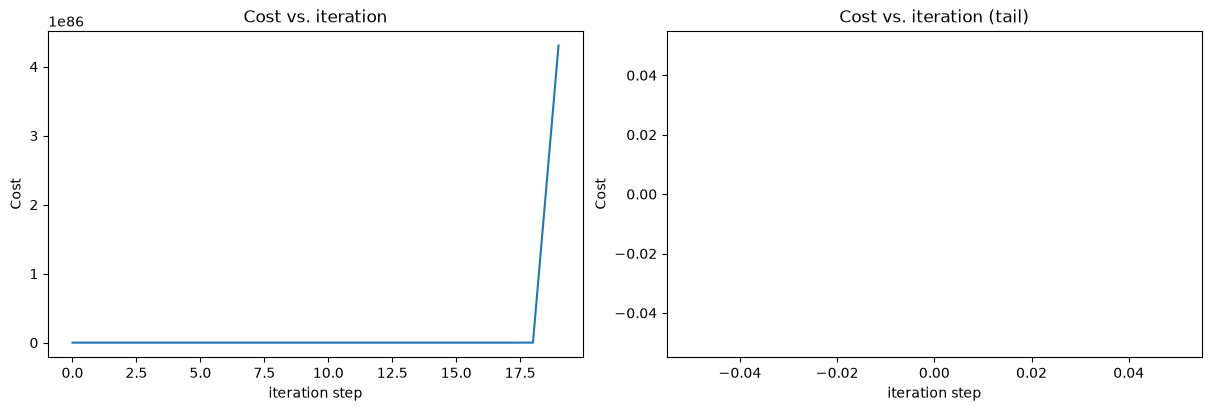

In [390]:
# plot cost versus iteration  
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 4))
ax1.plot(J_hist)
ax2.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])
ax1.set_title("Cost vs. iteration");  ax2.set_title("Cost vs. iteration (tail)")
ax1.set_ylabel('Cost')             ;  ax2.set_ylabel('Cost') 
ax1.set_xlabel('iteration step')   ;  ax2.set_xlabel('iteration step') 
plt.show()

Some graph intuition

In [377]:
x_features = ['Hours Studied',"Previous Scores","Extracurricular Activities","Sleep_Hours","Sample Question Papers Practiced","Performance Index"]

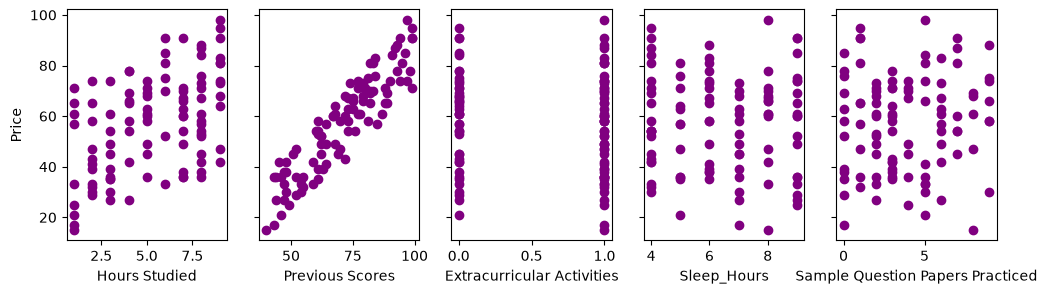

In [378]:
fig, ax = plt.subplots(1, 5, figsize=(12, 3), sharey=True)
for i in range(len(ax)):
    ax[i].scatter(x_train[:, i], y_train,c='purple')
    ax[i].set_xlabel(x_features[i])
ax[0].set_ylabel("Price")
plt.show()

Text(0, 0.5, 'Cost')

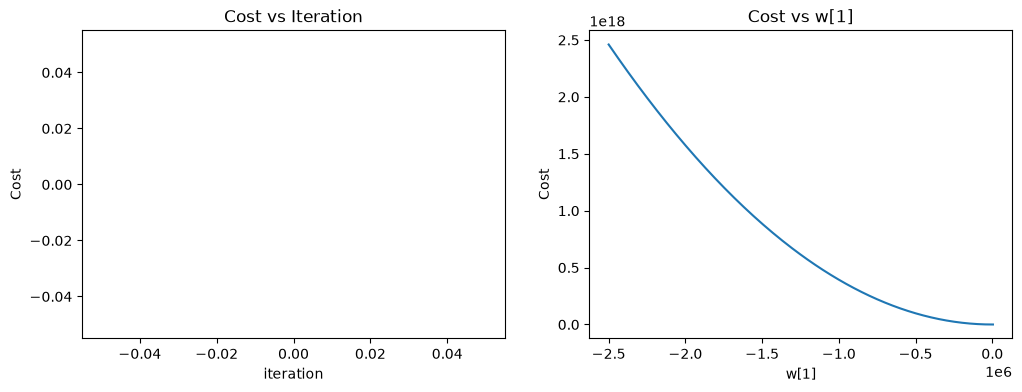

In [414]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(100 + np.arange(len(J_hist[100:])), J_hist[100:])

w_range = np.linspace(-2.5e+06, 4.3e+03, 200)

costs = []
for w in w_range:
    w_test = np.zeros(5)
    w_test[0] = w
    w_test[1] = w
    w_test[2] = w
    w_test[3] = w
    w_test[4] = w
    cost = compute_cost(x_train, y_train, w_test, -12.81)
    costs.append(cost)
    
ax2.plot(w_range, costs)
ax1.set_title('Cost vs Iteration')
ax1.set_xlabel('iteration')
ax1.set_ylabel('Cost')
ax2.set_title('Cost vs w[1]')
ax2.set_xlabel('w[1]')
ax2.set_ylabel('Cost')
#ax2.plot(w_1_hist, )

## Feature Scaling implementation